In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u

from astropy.wcs.utils import proj_plane_pixel_scales
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.nddata import Cutout2D
from DAHAD.DataStarred import ImageFits

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u

from astropy.wcs.utils import proj_plane_pixel_scales
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.nddata import Cutout2D


def add_en_arrows(
	ax,
	data,
	wcs,
	anchor=(0.75, 0.18),
	length_arcsec=1.0,
	color="white",
	fontsize=12,
	lw=2,):
	
	"""
	Add East and North arrows using the WCS.

	Parameters
	----------
	ax : matplotlib.axes.Axes
		Axis where the image is plotted.

	data : ndarray
		2D image data.

	wcs : astropy.wcs.WCS
		Celestial WCS of the image.

	anchor : tuple, optional
		Anchor position in fractional image coordinates (xfrac, yfrac).

	length_arcsec : float, optional
		Length of each compass arrow in arcsec.

	color : str, optional
		Arrow and label color.

	fontsize : int, optional
		Font size of the labels.

	lw : float, optional
		Arrow line width.
	"""
	ny, nx = data.shape

	# Anchor point in pixel coordinates
	x0 =  int(nx *0.9)
	y0 = int(0.2*ny)
	sky0 = wcs.pixel_to_world(x0, y0)

	# Move on the sky: North = PA 0 deg, East = PA 90 deg
	sky_north = sky0.directional_offset_by(0 * u.deg, length_arcsec * u.arcsec)
	sky_east = sky0.directional_offset_by(90 * u.deg, length_arcsec * u.arcsec)

	# Back to pixel coordinates
	xN, yN = wcs.world_to_pixel(sky_north)
	xE, yE = wcs.world_to_pixel(sky_east)
	cx = 0
	cy = 0
	if xE-x0<0:
		cx = data.shape[0]*0.02
	if yE-x0<0:
		cy = data.shape[0]*0.02
		print(cx)
	print(xE-x0, yE-y0)
	print(xN-x0, yN-y0)
	ax.annotate("",xy=(xN, yN),xytext=(x0, y0), arrowprops=dict(arrowstyle="-|>", color=color, lw=lw), annotation_clip=False)
	ax.text(xN,yN, "N", color=color,fontsize=fontsize, ha="right", va="center", clip_on=False,)

	
	ax.annotate("",xy=(xE+cx, yE+cy),xytext=(x0, y0),arrowprops=dict(arrowstyle="-|>", color=color, lw=lw),annotation_clip=False,)
	ax.text(xE,yE,"E",color=color,fontsize=fontsize,ha="center",va="center",clip_on=False,)


def plot_image_with_scalebar(
	data,
	wcs,
	title=None,
	scalebar_arcsec=1.0,
	percentiles=(1, 99),
	cmap="inferno",
	add_compass=True,
	compass_anchor=(0.75, 0.18),
	#compass_length_arcsec=0.5,
	compass_color="white",
	compass_fontsize=12,
	compass_lw=2,
	add_colorbar=False,
	colorbar_label="Flux",
	target_name = "",
	filter = ""
):
	"""
	Plot an astronomical image with an arcsec scale bar, optional E/N compass,
	and optional colorbar.

	Parameters
	----------
	data : ndarray
		2D image data.

	wcs : astropy.wcs.WCS
		WCS solution for the image.

	title : str, optional
		Plot title.

	scalebar_arcsec : float, optional
		Length of the scale bar in arcsec.

	percentiles : tuple, optional
		Percentile limits for display scaling.

	cmap : str, optional
		Colormap for the image.

	add_compass : bool, optional
		If True, draw the East/North compass.

	compass_anchor : tuple, optional
		Compass anchor in fractional image coordinates.

	compass_length_arcsec : float, optional
		Length of the compass arrows in arcsec. This is independent of the
		scale bar size.

	compass_color : str, optional
		Color of the compass arrows and labels.

	compass_fontsize : int, optional
		Font size of compass labels.

	compass_lw : float, optional
		Line width of compass arrows.

	add_colorbar : bool, optional
		If True, add a colorbar.

	colorbar_label : str, optional
		Label for the colorbar.
	"""
	wcs_cel = wcs.celestial

	vmin, vmax = np.nanpercentile(data, percentiles)

	fig, ax = plt.subplots(figsize=(6, 6))
	fig.canvas.draw()
	im = ax.imshow(data,origin="lower",cmap=cmap,vmin=vmin,vmax=vmax,)

	ax.set_xticks([])
	ax.set_yticks([])

	if title is not None:
		ax.set_title(title, fontsize=14)

	pixscale = proj_plane_pixel_scales(wcs_cel) * u.deg
	pixscale_arcsec = np.mean(pixscale.to(u.arcsec).value)

	scalebar_pix = scalebar_arcsec / pixscale_arcsec
	compass_length_arcsec = int(data.shape[0]*0.1) *  pixscale_arcsec
 	#print(compass_length_arcsec/ )
	#if not compass_length_arcsec:
	#compass_length_arcsec = data.shape[0]*0.012
		#print(compass_length_arcsec/data.shape[0])
	# Scale bar position
	x0 = 0.12 * data.shape[1]
	y0 = 0.10 * data.shape[0]

	ax.plot(
		[x0, x0 + scalebar_pix],
		[y0, y0],
		color="white",
		lw=3,
	)

	ax.text(
		x0 + scalebar_pix / 2,
		y0 + 0.04 * data.shape[0],
		f'{scalebar_arcsec:g}"',
		color="white",
		ha="center",
		va="bottom",
		fontsize=12,
	)

	if add_compass:
		add_en_arrows(ax=ax,data=data, wcs=wcs_cel, anchor=compass_anchor, length_arcsec=compass_length_arcsec, color=compass_color, fontsize=compass_fontsize, lw=compass_lw,)
	text = ""
	text += target_name
	text += "\n" + filter
  		#ax.text(0.2,0.95,target_name, color="white", ha="center",va="top",fontsize=12,transform=ax.transAxes)
	if len(text):
		ax.text(0.2,0.95,text, color="white", ha="center",va="top",fontsize=12,transform=ax.transAxes)
		
	
	if add_colorbar:
		divider = make_axes_locatable(ax)
		cax = divider.append_axes("right", size="4%", pad=0.05)
		cbar = fig.colorbar(im, cax=cax)
		cbar.set_label(colorbar_label)

	plt.tight_layout()
	plt.show()

In [158]:
path_data = "/home/felipe/work/Data/mast_data/JWST/mastDownload/JWST/jw02046-o003_t003_miri_f560w/jw02046-o003_t003_miri_f560w_i2d.fits"
#path_data = "/home/felipe/work/Data/mast_data/WFIJ2033/JWST/mastDownload/JWST/jw02046-o021_t020_miri_f560w/jw02046-o021_t020_miri_f560w_i2d.fits"
#path_data = "/home/felipe/work/Data/mast_data/WFIJ2033/JWST/mastDownload/JWST/jw01198-o004_t004_nircam_clear-f115w/jw01198-o004_t004_nircam_clear-f115w_i2d.fits"
#path_data = "/home/felipe/work/Data/mast_data/WFIJ2033/HST/mastDownload/HST/hst_skycell-p0410x14y05_wfc3_uvis_f814w_all/hst_skycell-p0410x14y05_wfc3_uvis_f814w_all_drc.fits"

In [159]:
jeje = ImageFits(path_data)

Set DATE-AVG to '2023-07-30T20:52:50.434' from MJD-AVG.
Set DATE-END to '2023-07-30T20:54:42.802' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -33.700495 from OBSGEO-[XYZ].
Set OBSGEO-H to 1694646708.745 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [160]:
jeje.header0

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
DATE    = '2025-12-28T00:26:45.351' / UTC date file created                     
ORIGIN  = 'STSCI   '           / Organization responsible for creating file     
TIMESYS = 'UTC     '           / principal time system for time-related keywords
TIMEUNIT= 's       '           / Default unit applicable to all time values     
FILENAME= 'jw02046-o003_t003_miri_f560w_i2d.fits' / Name of the file            
SDP_VER = '2025_4a '           / Data Processing (DP) Software Version          
PRD_VER = 'PRDOPSSOC-072'      / S&OC Project Reference Database (PRD) Version  
OSS_VER = '8.7     '           / Observatory Scheduling Software (OSS) Version  
GSC_VER = 'GSC31   '        

In [161]:
from astropy.coordinates import SkyCoord
sky_pointing = SkyCoord(jeje.RA,jeje.DEC,unit="deg",)

# height_cut =  * u.arcsec
# width_cut = cut_size * u.arcsec

cutout_2d = Cutout2D(jeje.data_raw, sky_pointing, 41 ,wcs=jeje.wcs,)

In [162]:
jeje.DEC

-16.59530000000001

In [163]:
jeje.TARGNAME

'WISEJ0259-1635'

0
1.0144047940886196 -3.8692354722974898
-3.8692354927551094 -1.014404782169855


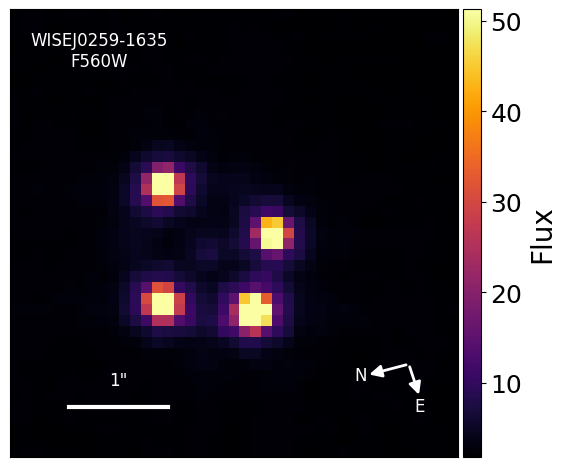

In [164]:
plot_image_with_scalebar(cutout_2d.data,cutout_2d.wcs,add_colorbar=True,target_name=jeje.TARGNAME,filter=jeje.FILTER)

In [8]:
jeje.EXPTIME